# Detector de Fraudes com Redes Neurais
`
Dessa vez, será utilizado um modelo de aprendizado profundo para obter melhores resultados
`

In [23]:
# Caso não tiver o arquivo, baixe-o usando o comando abaixo:
!wget "https://raw.githubusercontent.com/arthur-202/Portfolio/refs/heads/main/database__/df.csv"

--2026-02-11 00:21:22--  https://raw.githubusercontent.com/arthur-202/Portfolio/refs/heads/main/database__/df.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7019170 (6.7M) [text/plain]
Saving to: ‘df.csv.1’

df.csv.1            100%[===================>]   6.69M  25.6MB/s    in 0.3s    

2026-02-11 00:21:23 (25.6 MB/s) - ‘df.csv.1’ saved [7019170/7019170]



In [24]:
import pandas as pd

df = pd.read_csv("df.csv")
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [25]:
# Verificando os atributos do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [26]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age',
       'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')

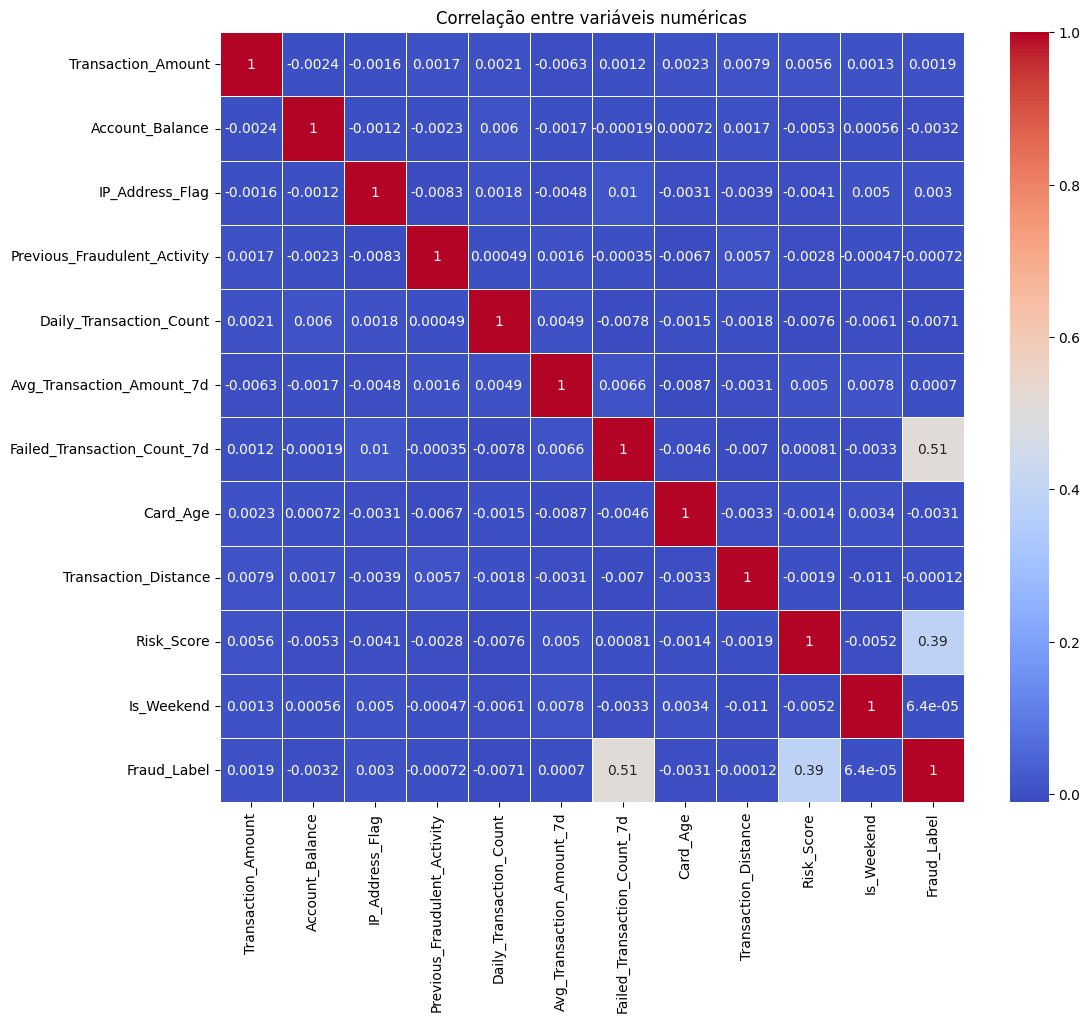

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlações entre as variáveis numéricas
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlação entre variáveis numéricas")
plt.show()

In [28]:
# Identificando as colunas categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns

In [29]:
total_unique_values = df[categorical_cols].nunique()
print(total_unique_values)

Transaction_ID           50000
User_ID                   8963
Transaction_Type             4
Timestamp                47724
Device_Type                  3
Location                     5
Merchant_Category            5
Card_Type                    4
Authentication_Method        4
dtype: int64


In [30]:
new_df = df.copy()
new_df = new_df.drop(columns=["Transaction_ID", "User_ID", "Timestamp", "Location"])

In [31]:
categorical_cols = new_df.select_dtypes(include=["object"]).columns
numeric_cols = new_df.select_dtypes(include=["int64", "float64"]).columns

In [32]:
# Priorizar os casos em que a variável "Fraud_Label" é igual a 1 (fraude)
fraud_cases = new_df[new_df["Fraud_Label"] == 1]
not_fraud_cases = len(new_df[new_df["Fraud_Label"] == 0])

print(f"Total de casos de fraude: {len(fraud_cases)}")
print(f"Total de casos não fraude: {not_fraud_cases}")

Total de casos de fraude: 16067
Total de casos não fraude: 33933


In [33]:
# Criando meu próprio split de treino e teste, priorizando os casos de fraude
def split_data(df, target, random_state=42):
    # Separando as features e o target
    X = df.drop(columns=[target])
    y = df[target]
    
    # calculando o número de amostras para treino e teste, priorizando os casos de fraude para o treino 
    n_global = len(df)
    n_train = int(0.8 * n_global)

    # positivos
    pos_idx = y[y==1].index
    neg_idx = y[y==0].index
    
    n_pos_train = int(0.6 * len(pos_idx))
    n_neg_train = n_train - n_pos_train

    # Amostragem dos índices para treino e teste
    pos_train_idx = pos_idx.to_series().sample(
        n=n_pos_train, random_state=random_state
    ).index

    neg_train_idx = neg_idx.to_series().sample(
        n=n_neg_train, random_state=random_state
    ).index

    train_idx = pos_train_idx.union(neg_train_idx)
    test_idx = df.index.difference(train_idx)

    # Separação dos dados de treino e teste
    X_train = X.loc[train_idx]
    y_train = y.loc[train_idx]
    X_test = X.loc[test_idx]
    y_test = y.loc[test_idx]

    return X_train, y_train, X_test, y_test


In [34]:
x_train, y_train, x_test, y_test = split_data(new_df, target="Fraud_Label")

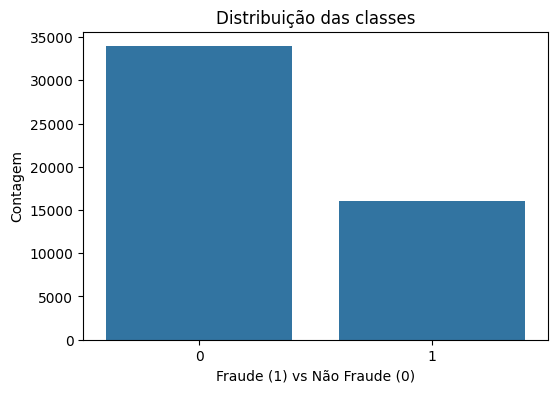

In [35]:
# Visualização da distribuição das classes
plt.figure(figsize=(6, 4))
sns.countplot(x="Fraud_Label", data=df)
plt.title("Distribuição das classes")
plt.xlabel("Fraude (1) vs Não Fraude (0)")
plt.ylabel("Contagem")
plt.show()

In [36]:
from sklearn.preprocessing import OneHotEncoder
# One-Hot Encoding para as colunas categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

In [104]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


def create_model(dropout_rate=0.5):
    model = keras.Sequential(
        layers=[
            layers.Dense(units=64, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(units=32, activation="relu"),
            layers.Dropout(dropout_rate - 0.2),
            layers.Dense(units=16, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(units=1, activation="sigmoid"),
        ],
    )
    return model

In [132]:
from keras.metrics import Precision, Recall, AUC
from keras.optimizers import Adam

model = create_model(dropout_rate=0.2)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy", Precision(), Recall(), AUC()]
)

In [133]:
# Verificando quais colunas normalizar ou não
x_train.max()

,0
Transaction_Amount,1174.14
Transaction_Type,POS
Account_Balance,99998.31
Device_Type,Tablet
Merchant_Category,Travel
IP_Address_Flag,1
Previous_Fraudulent_Activity,1
Daily_Transaction_Count,14
Avg_Transaction_Amount_7d,500.0
Failed_Transaction_Count_7d,4


`
As colunas: "Transaction_Amount", "Account_Balance", "Avg_Transaction_Amount_7d", "Failed_Transaction_Count_7d", "Transaction_Distance"
`

In [134]:
normalize_cols = ["Transaction_Amount", "Account_Balance",
 "Avg_Transaction_Amount_7d", "Failed_Transaction_Count_7d", "Transaction_Distance"]



In [135]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_cols),
        ("num_norm", num_pipeline, normalize_cols)
    ],
    remainder="passthrough"
)


In [136]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])


In [137]:
# Treinando o modelo
pipeline.fit(x_train, y_train, model__epochs=200, model__validation_split=0.2, model__callbacks=[EarlyStopping(patience=7)])

Epoch 1/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6513 - auc_11: 0.5128 - loss: 1.0013 - precision_11: 0.2462 - recall_11: 0.2183 - val_accuracy: 0.7588 - val_auc_11: 0.5602 - val_loss: 0.5967 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 2/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7334 - auc_11: 0.5184 - loss: 0.6117 - precision_11: 0.2424 - recall_11: 0.0514 - val_accuracy: 0.7588 - val_auc_11: 0.5550 - val_loss: 0.5681 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 3/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7570 - auc_11: 0.5245 - loss: 0.5821 - precision_11: 0.3031 - recall_11: 0.0071 - val_accuracy: 0.7588 - val_auc_11: 0.5755 - val_loss: 0.5589 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00
Epoch 4/200
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7614 - auc_11: 0.5370 - loss: 0.5669 - precision_11: 0.2361 - recall_11: 0.0015 - val_accuracy: 0.7588 - val_auc_11: 0

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  Index(['Transaction_Type', 'Device_Type', 'Merchant_Category', 'Card_Type',
       'Authentication_Method'],
      dtype='object')),
                                                 ('num_norm',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Transaction_Amount',
                                                   'Account_Balance',
                                                   'Avg_Transaction_Amount_7d',
                                                   'Failed_Transaction_Count_7d',
                                                   'Transaction_Distance'])])),
                ('model', <Sequential name=sequential_6, built=True>)])

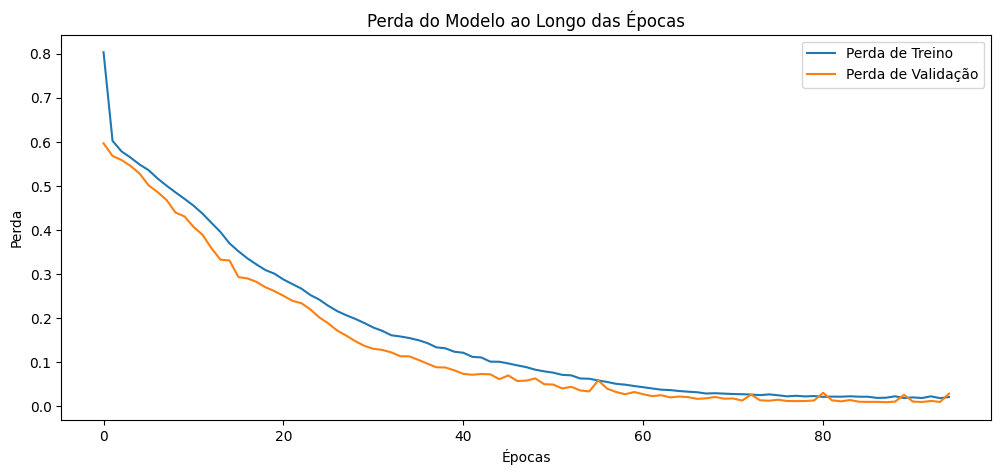

In [138]:
model = pipeline.named_steps["model"]
history = model.history.history

# Vizualização da perda do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history["loss"], label="Perda de Treino")
plt.plot(history["val_loss"], label="Perda de Validação")
plt.title("Perda do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.legend()
plt.show()

In [141]:
history.keys()

dict_keys(['accuracy', 'auc_11', 'loss', 'precision_11', 'recall_11', 'val_accuracy', 'val_auc_11', 'val_loss', 'val_precision_11', 'val_recall_11'])

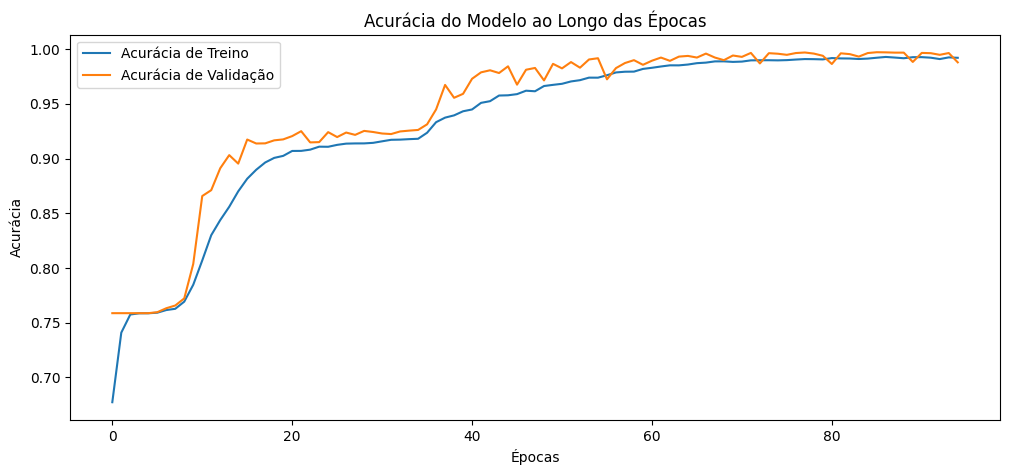

In [139]:
# Visualização da acurácia do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history["accuracy"], label="Acurácia de Treino")
plt.plot(history["val_accuracy"], label="Acurácia de Validação")
plt.title("Acurácia do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.show()

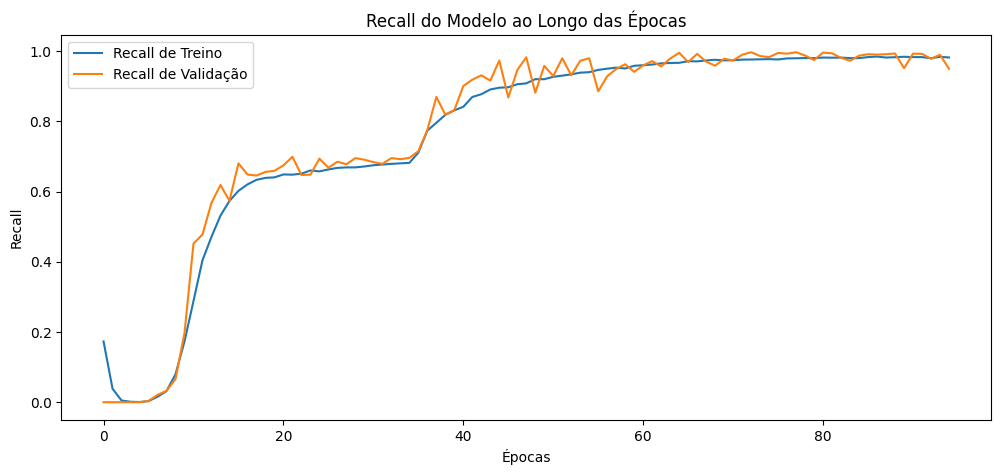

In [142]:
# Visualização do recall do modelo ao longo das épocas
plt.figure(figsize=(12, 5))
plt.plot(history["recall_11"], label="Recall de Treino")
plt.plot(history["val_recall_11"], label="Recall de Validação")
plt.title("Recall do Modelo ao Longo das Épocas")
plt.xlabel("Épocas")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [143]:
from sklearn.metrics import confusion_matrix

y_pred = pipeline.predict(x_test)
y_pred_classes = (y_pred >= 0.1).astype(int)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


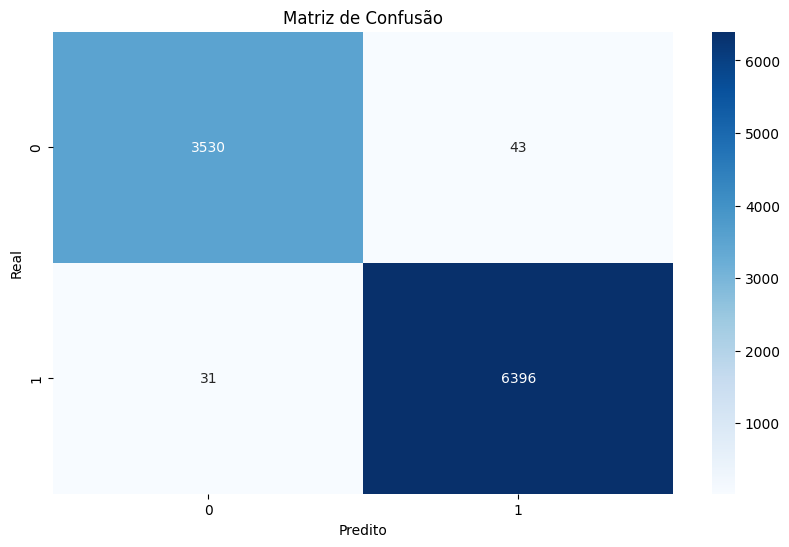

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [144]:
precision = Precision()
recall = Recall()
auc = AUC()

In [145]:
precision.update_state(y_test, y_pred_classes)
recall.update_state(y_test, y_pred_classes)
auc.update_state(y_test, y_pred_classes)

print(f"Precision: {precision.result().numpy():.4f}")
print(f"Recall: {recall.result().numpy():.4f}")
print(f"AUC: {auc.result().numpy():.4f}")

Precision: 0.9987
Recall: 0.9832
AUC: 0.9905


In [147]:
count_fraud = (y_test == 1).sum()
count_not_fraud = (y_test == 0).sum()

print(f"Total de casos de fraude no teste: {count_fraud}")
print(f"Total de casos de não fraude no teste: {count_not_fraud}")

Total de casos de fraude no teste: 6427
Total de casos de não fraude no teste: 3573


In [148]:
# Diminuindo o número de positivos para o teste, para analisar o comportamento do modelo em um cenário mais desafiador
x_test_challenging = x_test.copy()
y_test_challenging = y_test.copy()


In [149]:
# Filtrando os casos de fraude (1) e mantendo apenas uma parte dos casos de não fraude (0)
fraud_cases_test = y_test_challenging[y_test_challenging == 1].index
not_fraud_cases_test = y_test_challenging[y_test_challenging == 0].index

# Mantendo todos os casos de não fraude e apenas 20% dos casos de fraude
not_fraud_cases_test = not_fraud_cases_test.to_series().sample(frac=1.0, random_state=42).index
fraud_cases_test = fraud_cases_test.to_series().sample(frac=0.2, random_state=42).index

challenging_idx = not_fraud_cases_test.union(fraud_cases_test)

x_test_challenging = x_test_challenging.loc[challenging_idx]
y_test_challenging = y_test_challenging.loc[challenging_idx]

In [150]:
# Verificando a quantidade de casos de fraude e não fraude nesse cenário 
count_fraud_challenging = (y_test_challenging == 1).sum()
count_not_fraud_challenging = (y_test_challenging == 0).sum()

print(f"Total de casos de fraude no teste desafiador: {count_fraud_challenging}")
print(f"Total de casos de não fraude no teste desafiador: {count_not_fraud_challenging}")

Total de casos de fraude no teste desafiador: 1285
Total de casos de não fraude no teste desafiador: 3573


In [151]:
Y_pred_challenging = pipeline.predict(x_test_challenging)
y_pred_classes_challenging = (Y_pred_challenging >= 0.1).astype(int)

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


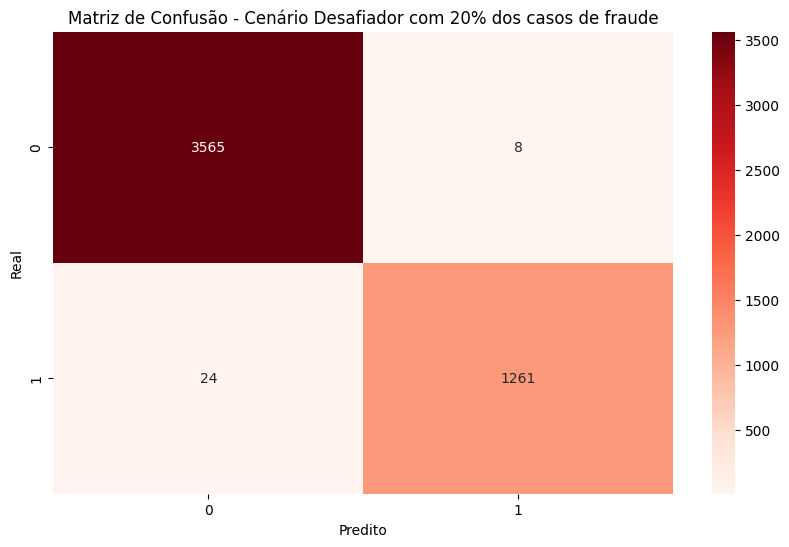

In [152]:
# Verificando como o modelo se comporta em um cenário mais desafiador
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test_challenging, y_pred_classes_challenging), annot=True, fmt="d", cmap="Reds")
plt.title("Matriz de Confusão - Cenário Desafiador com 20% dos casos de fraude")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [154]:
precision.update_state(y_test_challenging, Y_pred_challenging)
recall.update_state(y_test_challenging, Y_pred_challenging)
auc.update_state(y_test_challenging, Y_pred_challenging)

print(f"Precision (Cenário Desafiador - 20%): {precision.result().numpy():.4f}")
print(f"Recall (Cenário Desafiador - 20%): {recall.result().numpy():.4f}")
print(f"AUC (Cenário Desafiador - 20%): {auc.result().numpy():.4f}")

Precision (Cenário Desafiador - 20%): 0.9986
Recall (Cenário Desafiador - 20%): 0.9738
AUC (Cenário Desafiador - 20%): 0.9935


In [160]:
x_test_challenging = x_test.copy()
y_test_challenging = y_test.copy()

# Filtrando os casos de fraude (1) e mantendo apenas uma parte dos casos de não fraude (0)
fraud_cases_test = y_test_challenging[y_test_challenging == 1].index
not_fraud_cases_test = y_test_challenging[y_test_challenging == 0].index

# Mantendo todos os casos de não fraude e apenas 2% dos casos de fraude
not_fraud_cases_test = not_fraud_cases_test.to_series().sample(frac=1.0, random_state=42).index
fraud_cases_test = fraud_cases_test.to_series().sample(frac=0.02, random_state=42).index

challenging_idx = not_fraud_cases_test.union(fraud_cases_test)

x_test_challenging = x_test_challenging.loc[challenging_idx]
y_test_challenging = y_test_challenging.loc[challenging_idx]

In [161]:
cont_fraud = (y_test_challenging == 1).sum()
cont_not_fraud = (y_test_challenging == 0).sum()

print(f"Total de casos de fraude no teste desafiador (2%): {cont_fraud}")
print(f"Total de casos de não fraude no teste desafiador (2%): {cont_not_fraud}")

Total de casos de fraude no teste desafiador (2%): 129
Total de casos de não fraude no teste desafiador (2%): 3573


In [162]:
Y_pred_challenging = pipeline.predict(x_test_challenging)
y_pred_classes_challenging = (Y_pred_challenging >= 0.1).astype(int)

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [163]:
precision.update_state(y_test_challenging, Y_pred_challenging)
recall.update_state(y_test_challenging, Y_pred_challenging)
auc.update_state(y_test_challenging, Y_pred_challenging)

print(f"Precision (Cenário Desafiador - 2%): {precision.result().numpy():.4f}")
print(f"Recall (Cenário Desafiador - 2%): {recall.result().numpy():.4f}")
print(f"AUC (Cenário Desafiador - 2%): {auc.result().numpy():.4f}")

Precision (Cenário Desafiador - 2%): 0.9982
Recall (Cenário Desafiador - 2%): 0.9728
AUC (Cenário Desafiador - 2%): 0.9938


In [ ]:
# Verificando a quantidade de casos de fraude e não fraude nesse cenário extremamente desafiador
count_fraud_challenging = (y_test_challenging == 1).sum()
count_not_fraud_challenging = (y_test_challenging == 0).sum()

print(f"Total de casos de fraude no teste desafiador: {count_fraud_challenging}")
print(f"Total de casos de não fraude no teste desafiador: {count_not_fraud_challenging}")

Total de casos de fraude no teste desafiador: 129
Total de casos de não fraude no teste desafiador: 3573


In [164]:
# Mantendo todos os casos de não fraude e apenas 1.24% dos casos de fraude
# Esse cenário torna-se o mais importante de todos, já que a proporção de casos de fraude no mundo real é muito baixa, 
# e o modelo precisa ser capaz de identificar fraudes mesmo quando elas são extremamente raras.

x_test_challenging = x_test.copy()
y_test_challenging = y_test.copy()

# Filtrando os casos de fraude (1) e mantendo apenas uma parte dos casos de não fraude (0)
fraud_cases_test = y_test_challenging[y_test_challenging == 1].index
not_fraud_cases_test = y_test_challenging[y_test_challenging == 0].index

not_fraud_cases_test = not_fraud_cases_test.to_series().sample(frac=1.0, random_state=42).index
fraud_cases_test = fraud_cases_test.to_series().sample(frac=0.0124, random_state=42).index

challenging_idx = not_fraud_cases_test.union(fraud_cases_test)

x_test_challenging = x_test_challenging.loc[challenging_idx]
y_test_challenging = y_test_challenging.loc[challenging_idx]

In [165]:
Y_pred_challenging_potente = pipeline.predict(x_test_challenging)
y_pred_classes_challenging = (Y_pred_challenging_potente >= 0.1).astype(int)

115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [166]:
# Verificando a quantidade de casos de fraude e não fraude nesse cenário extremamente desafiador
count_fraud_challenging = (y_test_challenging == 1).sum()
count_not_fraud_challenging = (y_test_challenging == 0).sum()

print(f"Total de casos de fraude no teste desafiador: {count_fraud_challenging}")
print(f"Total de casos de não fraude no teste desafiador: {count_not_fraud_challenging}")

Total de casos de fraude no teste desafiador: 80
Total de casos de não fraude no teste desafiador: 3573


In [167]:
print(y_test_challenging.shape)
print(Y_pred_challenging_potente.shape)


(3653,)
(3653, 1)


In [169]:
precision.update_state(y_test_challenging, Y_pred_challenging_potente)
recall.update_state(y_test_challenging, y_pred_classes_challenging)
auc.update_state(y_test_challenging, Y_pred_challenging_potente)

print(f"Precision (Cenário Desafiador - 1.4%): {precision.result().numpy():.4f}")
print(f"Recall (Cenário Desafiador - 1.4%): {recall.result().numpy():.4f}")
print(f"AUC (Cenário Desafiador - 1.4%): {auc.result().numpy():.4f}")

Precision (Cenário Desafiador - 1.4%): 0.9978
Recall (Cenário Desafiador - 1.4%): 0.9730
AUC (Cenário Desafiador - 1.4%): 0.9939


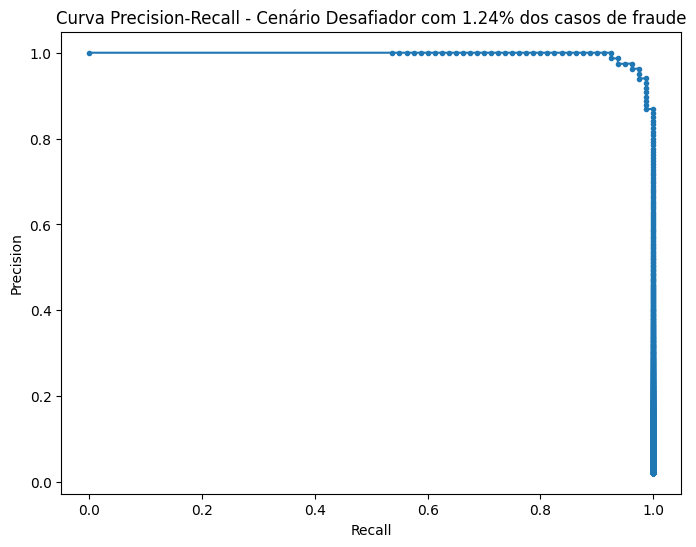

In [170]:
# Vizualização do gráfico recall vs precision para o cenário extremamente desafiador
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(y_test_challenging, Y_pred_challenging_potente)
plt.figure(figsize=(8, 6))
plt.plot(recall_values, precision_values, marker=".")
plt.title("Curva Precision-Recall - Cenário Desafiador com 1.24% dos casos de fraude")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

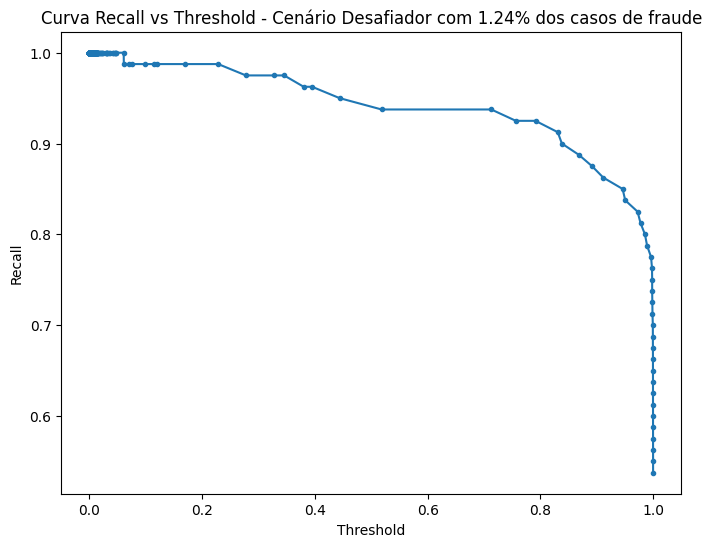

In [171]:
# Gráfico do recall vs threshold para o cenário extremamente desafiador
plt.figure(figsize=(8, 6))
plt.plot(thresholds, recall_values[:-1], marker=".")
plt.title("Curva Recall vs Threshold - Cenário Desafiador com 1.24% dos casos de fraude")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.show()

# Paper de avaliação;
*Testando com os dados da seguinte forma:*
**Ambos estão com 30 epochs**
`
n_positive_train - 0.6 : 

Precision: 0.9987
Recall: 0.9591
AUC: 0.9784
`

`
n_positive_train - 0.5:
Precision: 0.9999
Recall: 0.8652
AUC: 0.9323

`

**Ambos estão com 100 epochs e com EarlyStopping**
`
n_positive_train - 0.6
Precision: 0.9907
Recall: 0.9970
AUC: 0.9901
`

´
n_positive_train - 0.5
Precision: 0.9996
Recall: 0.9503
AUC: 0.9744
´

# Análise própria;

`
Quanto mais se utiliza dados positivos para o modelo ser treinado, mais chances você tem de obter um maior recall,
que é a nossa melhor métrica para esse treinamento.
`